# Station-15: a thick-web blade station — solid vs shell

Station 15 of the composite blade is a **thick-web** section: the spar webs are no longer thin relative to
their length, which is exactly where the reduced *shell* models begin to drift while the full **2-D solid**
stays exact. This tutorial runs **both** on the same station — the JAX 2-D solid on the (quadrilateral) solid
mesh and the KL / RM shells on the 1-D shell mesh — and benchmarks every term against the **VABS `.K`**.
Order $[\,EA,\;GA_2,\;GA_3,\;GJ,\;EI_2,\;EI_3\,]$.

In [1]:
import os, sys, time
import numpy as np
def _find_repo_root(d=None):
    d = os.path.abspath(d or os.getcwd())
    while True:
        if os.path.isdir(os.path.join(d, "examples", "data")) and os.path.isfile(os.path.join(d, "pyproject.toml")):
            return d
        parent = os.path.dirname(d)
        if parent == d:
            raise RuntimeError("OpenSG-TW repo root not found - run this notebook from inside the cloned repo")
        d = parent
CC = _find_repo_root()
for p in ("", "opensg_jax"):
    sys.path.insert(0, os.path.join(CC, p))
os.environ["CUDA_VISIBLE_DEVICES"] = ""
import jax; jax.config.update("jax_enable_x64", True)
np.set_printoptions(precision=4, linewidth=160, suppress=True)
from IPython.display import Image
from fe_jax.orient_plot import plot_orient
from opensg_jax.fe_jax.timo_report import (sym, pcterr, full_pcterr, diag_table, term_table,
                                          compare_terms, print_6x6, nonzero_terms, parse_vabs, wall_t, LBL)
print("ready | jax", jax.__version__)

ready | jax 0.9.2


In [2]:
DATA = os.path.join(CC, "examples", "data")
SHELL = os.path.join(DATA, "1d_yaml", "st15_shell.yaml")
SOLIDY = os.path.join(DATA, "2d_yaml", "st15_solid.yaml")          # quadrilateral 2-D solid mesh
# VABS .K Timoshenko 6x6 for station 15 [EA, GA2, GA3, GJ, EI2, EI3]
VK = np.array([
 [1.3082688863e10, 0, 0, 0, 1.4345965587e7, -3.5711027657e9],
 [0, 4.5798883250e8, -2.3551934467e7, -2.1795975869e7, 0, 0],
 [0, -2.3551934467e7, 1.0549929775e8, 5.0551071833e7, 0, 0],
 [0, -2.1795975869e7, 5.0551071833e7, 1.5604378583e8, 0, 0],
 [1.4345965587e7, 0, 0, 0, 1.6630291239e9, 2.5855045936e8],
 [-3.5711027657e9, 0, 0, 0, 2.5855045936e8, 5.1066629243e9]])
print("shell :", os.path.basename(SHELL))
print("solid :", os.path.basename(SOLIDY), "(quadrilateral mesh)")

shell : st15_shell.yaml
solid : st15_solid.yaml (quadrilateral mesh)


## Material orientation (solid + shell)

[orient_plot] SHELL: e3 OML->IML 62/64   e1_z mean=1.000


[orient_plot] SOLID: e3 OML->IML 438/470   e1_z mean=1.000


[orient_plot] wrote _img/st15_orient.png


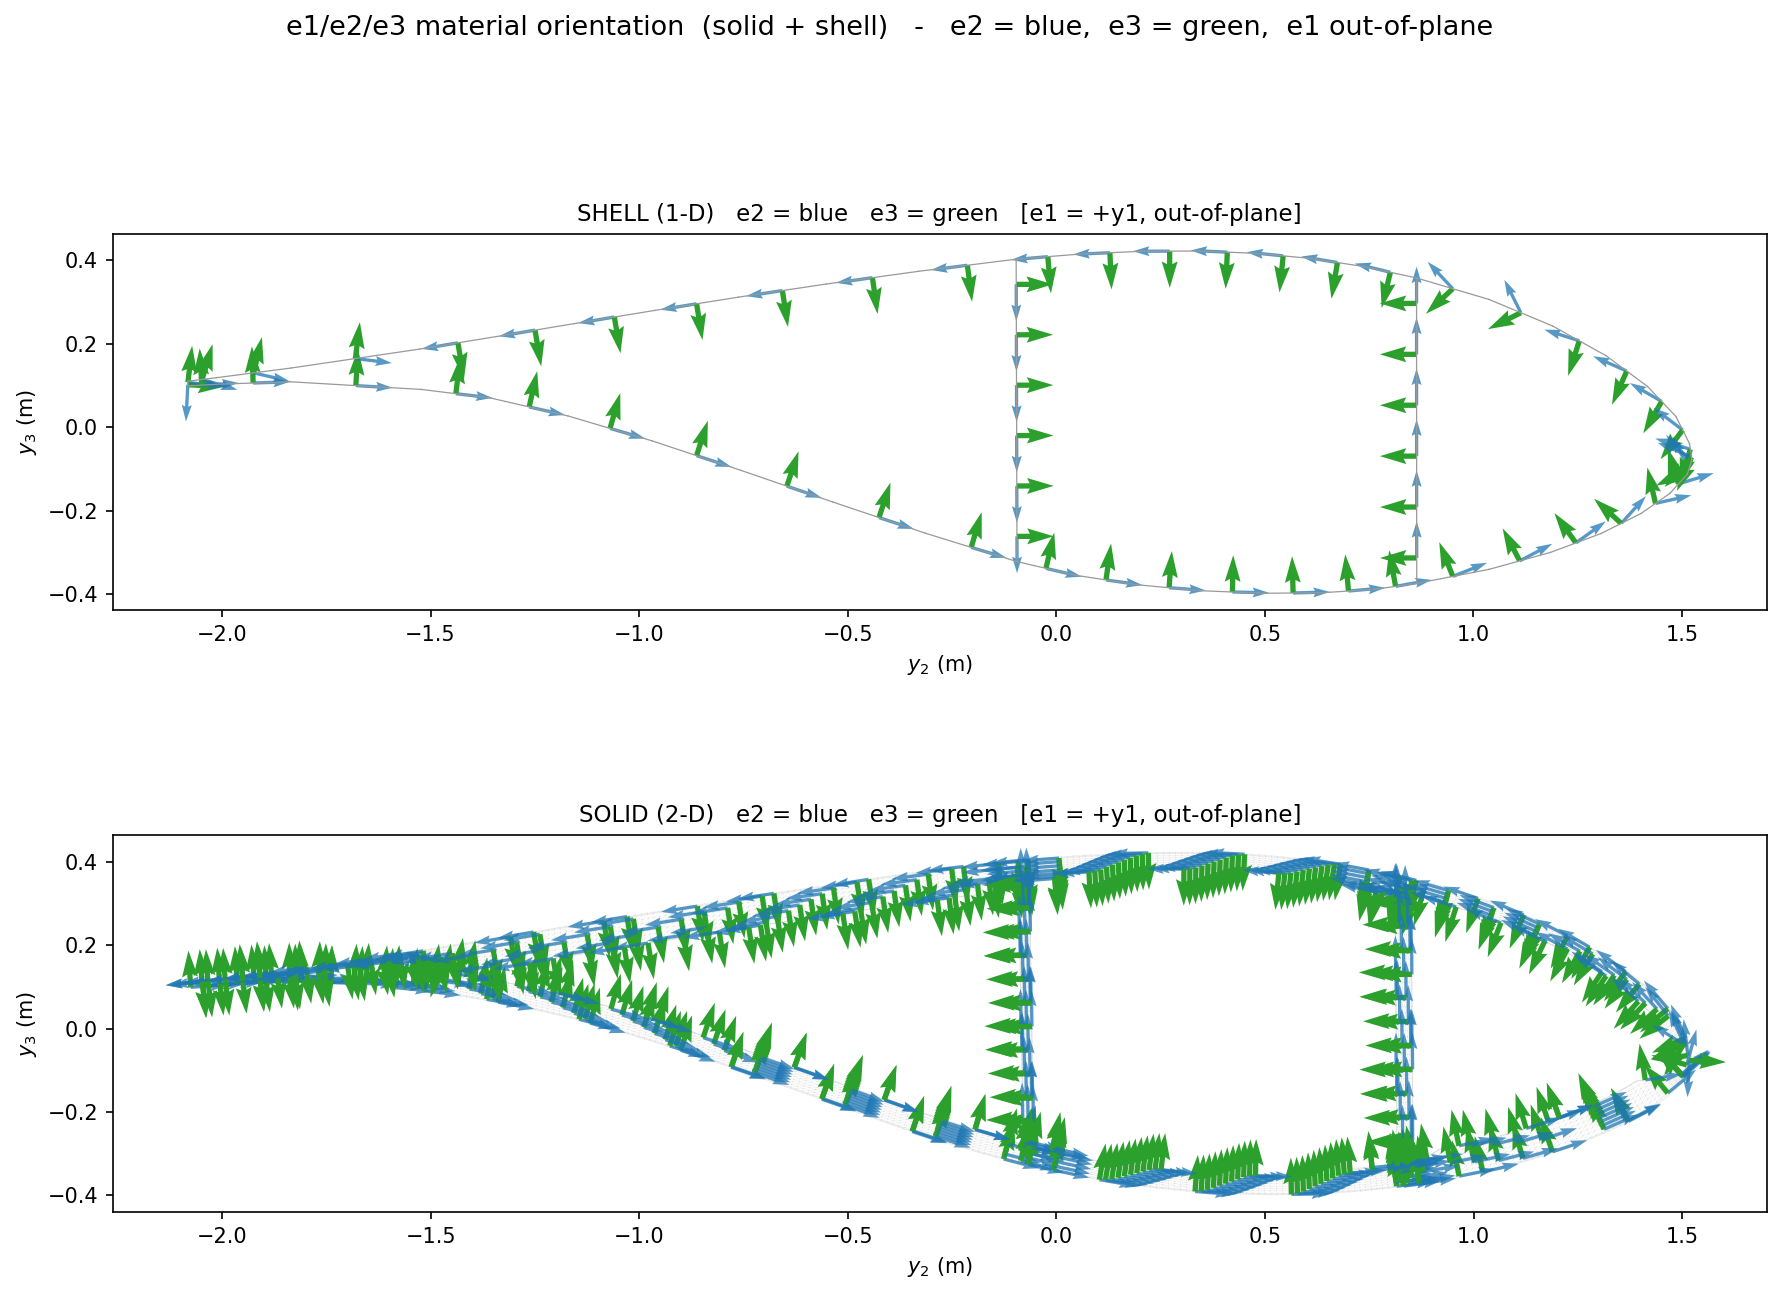

In [3]:
png = plot_orient(SHELL, SOLIDY, out_png=os.path.join(os.path.join(CC, "docs", "tutorials", "_img"), "st15_orient.png"))
Image(filename=png)

## Solid — full 6×6 vs VABS (quadrilateral mesh)

The 2-D solid mesh here is **quadrilateral**. The reader reorders the quad nodes to the basix lexicographic
convention, so the JAX solid reproduces VABS exactly — the same machine-precision agreement as the
triangle meshes.

In [4]:
from opensg_jax.fe_jax.solid_timo import compute_timo_from_yaml
C6 = sym(compute_timo_from_yaml(SOLIDY, verbose=False))
V = sym(VK)
print("JAX 2-D solid Timoshenko 6x6:")
print(C6)
print()
term_table("JAX-solid", C6, V)
print("\nFull 6x6 %-error vs VABS (terms >=1000x below max neglected -> 0):")
print(pcterr(C6, V))

JAX 2-D solid Timoshenko 6x6:
[[ 1.3083e+10  0.0000e+00  0.0000e+00  0.0000e+00  1.4346e+07 -3.5711e+09]
 [ 0.0000e+00  4.5799e+08 -2.3552e+07 -2.1795e+07  0.0000e+00  0.0000e+00]
 [ 0.0000e+00 -2.3552e+07  1.0550e+08  5.0551e+07  0.0000e+00  0.0000e+00]
 [ 0.0000e+00 -2.1795e+07  5.0551e+07  1.5604e+08  0.0000e+00  0.0000e+00]
 [ 1.4346e+07  0.0000e+00  0.0000e+00  0.0000e+00  1.6630e+09  2.5855e+08]
 [-3.5711e+09  0.0000e+00  0.0000e+00  0.0000e+00  2.5855e+08  5.1067e+09]]

  term              JAX-solid       benchmark       %err
  C11(EA)         1.30827e+10     1.30827e+10     -0.00
  C15             1.43456e+07     1.43460e+07     -0.00
  C16            -3.57110e+09    -3.57110e+09     -0.00
  C22(GA2)        4.57986e+08     4.57989e+08     -0.00
  C23            -2.35525e+07    -2.35519e+07     +0.00
  C24            -2.17950e+07    -2.17960e+07     -0.00
  C33(GA3)        1.05498e+08     1.05499e+08     -0.00
  C34             5.05506e+07     5.05511e+07     -0.00
  C44(GJ)    

## Shell — KL and RM (where the thick web shows)

In [5]:
from opensg_jax.fe_jax.gradient_kirchhoff import gradient_junction_kirchhoff
from opensg_jax.fe_jax.strip_RM import rm_timoshenko_6x6
C_kl = sym(gradient_junction_kirchhoff(SHELL, frac=0.0, dshift=None)[0])
C_rm = sym(rm_timoshenko_6x6(SHELL, 0.0, dshift=None, curved=False, shear="mitc"))
print_6x6(C_rm, "RM (1-D shell)"); print()
print_6x6(C_kl, "KL (1-D shell)")
print("\nRM, KL and the JAX 2-D solid vs the VABS .K reference - every non-zero Cij term:")
compare_terms(V, {"RM": C_rm, "KL": C_kl, "solid": C6})

[orient_plot] SHELL: e3 OML->IML 62/64   e1_z mean=1.000


[orient_plot] wrote ../../examples/data/1d_yaml/st15_shell_orient_e1e2e3.png


RM (1-D shell) Timoshenko 6x6  [EA, GA2, GA3, GJ, EI2, EI3]:
    1.33259e+10   0.00000e+00   0.00000e+00   0.00000e+00   2.74908e+07  -3.24120e+09
    0.00000e+00   4.42623e+08  -2.15563e+07  -2.45391e+07   0.00000e+00   0.00000e+00
    0.00000e+00  -2.15563e+07   9.51861e+07   4.80457e+07   0.00000e+00   0.00000e+00
    0.00000e+00  -2.45391e+07   4.80457e+07   1.48666e+08   0.00000e+00   0.00000e+00
    2.74908e+07   0.00000e+00   0.00000e+00   0.00000e+00   1.67106e+09   2.97772e+08
   -3.24120e+09   0.00000e+00   0.00000e+00   0.00000e+00   2.97772e+08   5.80923e+09

KL (1-D shell) Timoshenko 6x6  [EA, GA2, GA3, GJ, EI2, EI3]:
    1.33258e+10   1.22198e+03  -6.24215e+03  -3.16699e+03   2.73877e+07  -3.24145e+09
    1.22198e+03   4.45290e+08  -2.16850e+07  -2.46989e+07   2.45185e+02   9.48649e+03
   -6.24215e+03  -2.16850e+07   9.53128e+07   4.84514e+07  -2.60214e+03  -3.47941e+03
   -3.16699e+03  -2.46989e+07   4.84514e+07   1.49860e+08  -1.31200e+03  -2.03875e+03
    2.73877e+07  

{'RM': np.float64(91.6273749252616),
 'KL': np.float64(90.9086017640481),
 'solid': np.float64(0.004648993246424971)}

## Takeaway

The **2-D solid** reproduces the VABS station-15 stiffness to machine precision, **including on a
quadrilateral mesh**. The reduced **shell** models track the classical terms ($EA$, $EI_2$) closely but
drift on the thick-web-sensitive terms (notably $EI_3$ and the transverse shears) — the signal that, for
thick-web stations, the 2-D solid is the model to trust. KL and RM agree closely here because the walls,
though thick, are not soft-core; the RM advantage is largest on composite *thin*-wall shear
({doc}`rm_timo_from_yaml`).